In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

In [2]:
summer=pd.read_csv('./summer.csv')
winter=pd.read_csv('./winter.csv')
dictionary=pd.read_csv('./dictionary.csv')


Which countries and athletes have won the most medals at the Olympic games?

In [3]:
summer_and_winter=pd.concat([summer,winter])
summer_and_winter.groupby(['Country','Athlete'])['Medal'].count().sort_values(ascending=False)

Country  Athlete               
USA      PHELPS, Michael           22
URS      LATYNINA, Larisa          18
         ANDRIANOV, Nikolay        15
         SHAKHLIN, Boris           13
NOR      BJOERNDALEN, Ole Einar    13
                                   ..
GDR      HERBST, Christine          1
         HEPPNER, Uwe               1
         HENNINGER, Egon            1
         HENNIG, Roland             1
ZZX      WINCKLER, Charles          1
Name: Medal, Length: 26859, dtype: int64

## Inspecting Datasets

In [4]:
summer.head()

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1896,Athens,Aquatics,Swimming,"HAJOS, Alfred",HUN,Men,100M Freestyle,Gold
1,1896,Athens,Aquatics,Swimming,"HERSCHMANN, Otto",AUT,Men,100M Freestyle,Silver
2,1896,Athens,Aquatics,Swimming,"DRIVAS, Dimitrios",GRE,Men,100M Freestyle For Sailors,Bronze
3,1896,Athens,Aquatics,Swimming,"MALOKINIS, Ioannis",GRE,Men,100M Freestyle For Sailors,Gold
4,1896,Athens,Aquatics,Swimming,"CHASAPIS, Spiridon",GRE,Men,100M Freestyle For Sailors,Silver


In [5]:
summer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31165 entries, 0 to 31164
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        31165 non-null  int64 
 1   City        31165 non-null  object
 2   Sport       31165 non-null  object
 3   Discipline  31165 non-null  object
 4   Athlete     31165 non-null  object
 5   Country     31161 non-null  object
 6   Gender      31165 non-null  object
 7   Event       31165 non-null  object
 8   Medal       31165 non-null  object
dtypes: int64(1), object(8)
memory usage: 2.1+ MB


In [6]:
winter.head()

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1924,Chamonix,Biathlon,Biathlon,"BERTHET, G.",FRA,Men,Military Patrol,Bronze
1,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, C.",FRA,Men,Military Patrol,Bronze
2,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, Maurice",FRA,Men,Military Patrol,Bronze
3,1924,Chamonix,Biathlon,Biathlon,"VANDELLE, André",FRA,Men,Military Patrol,Bronze
4,1924,Chamonix,Biathlon,Biathlon,"AUFDENBLATTEN, Adolf",SUI,Men,Military Patrol,Gold


In [7]:
winter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5770 entries, 0 to 5769
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        5770 non-null   int64 
 1   City        5770 non-null   object
 2   Sport       5770 non-null   object
 3   Discipline  5770 non-null   object
 4   Athlete     5770 non-null   object
 5   Country     5770 non-null   object
 6   Gender      5770 non-null   object
 7   Event       5770 non-null   object
 8   Medal       5770 non-null   object
dtypes: int64(1), object(8)
memory usage: 405.8+ KB


In [8]:
dictionary.head()

,Country,Code,Population,GDP per Capita
0,Afghanistan,AFG,32526562.0,594.323081
1,Albania,ALB,2889167.0,3945.217582
2,Algeria,ALG,39666519.0,4206.031232
3,American Samoa*,ASA,55538.0,NaN
4,Andorra,AND,70473.0,NaN


In [9]:
dictionary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         201 non-null    object 
 1   Code            201 non-null    object 
 2   Population      196 non-null    float64
 3   GDP per Capita  176 non-null    float64
dtypes: float64(2), object(2)
memory usage: 6.4+ KB


In [10]:
summer[summer.isna().values]=summer[summer.isna().values].fillna('UK')

In [11]:
dictionary[dictionary.isna().values]

,Country,Code,Population,GDP per Capita
3,American Samoa*,ASA,55538.0,NaN
4,Andorra,AND,70473.0,NaN
9,Aruba*,ARU,103889.0,NaN
20,Bermuda*,BER,65235.0,NaN
27,British Virgin Islands,IVB,30117.0,NaN
36,Cayman Islands*,CAY,59967.0,NaN
45,Cook Islands,COK,NaN,NaN
45,Cook Islands,COK,NaN,NaN
49,Cuba,CUB,11389562.0,NaN
61,Eritrea,ERI,NaN,NaN


Can you find the highest male / female athletes of all time in the Summer editions?

In [12]:
summer.head(1)

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1896,Athens,Aquatics,Swimming,"HAJOS, Alfred",HUN,Men,100M Freestyle,Gold


In [13]:
summer.groupby(['Athlete','Gender'],as_index=False)['Medal'].count().sort_values(by='Medal',ascending=False).head(8)


,Athlete,Gender,Medal
15703,"PHELPS, Michael",Men,22
11203,"LATYNINA, Larisa",Women,18
511,"ANDRIANOV, Nikolay",Men,15
14884,"ONO, Takashi",Men,13
12477,"MANGIAROTTI, Edoardo",Men,13
18116,"SHAKHLIN, Boris",Men,13
3737,"COUGHLIN, Natalie",Women,12
5760,"FISCHER, Birgit",Women,12


Find the highest athletes regarding to each medal type in the Summer editions?

In [14]:
summer.groupby(['Athlete','Gender'])['Medal'].value_counts().sort_values(ascending=False).head(10)

Athlete           Gender  Medal
PHELPS, Michael   Men     Gold     18
SPITZ, Mark       Men     Gold      9
LEWIS, Carl       Men     Gold      9
LATYNINA, Larisa  Women   Gold      9
NURMI, Paavo      Men     Gold      9
THOMPSON, Jenny   Women   Gold      8
EWRY, Ray         Men     Gold      8
BIONDI, Matthew   Men     Gold      8
FISCHER, Birgit   Women   Gold      8
KATO, Sawao       Men     Gold      8
Name: count, dtype: int64

Which are the most successful countries in both Summer and Winter editions?

In [15]:
summer_and_winter=pd.concat([summer,winter])
summer_and_winter.groupby(['Country','Medal'])['Medal'].count().sort_values(ascending=False).head(10)

Country  Medal 
USA      Gold      2402
         Silver    1571
         Bronze    1265
URS      Gold      1088
         Silver     724
         Bronze     677
GBR      Silver     632
GER      Gold       589
GBR      Bronze     587
         Gold       580
Name: Medal, dtype: int64

What are the Top 10 Countries by total medals?

In [16]:
summer_and_winter.groupby(['Country'],as_index=False)['Medal'].count().sort_values(by='Medal',ascending=False).head(10)

,Country,Medal
141,USA,5238
139,URS,2489
47,GBR,1799
50,GER,1665
44,FRA,1548
68,ITA,1488
122,SWE,1477
21,CAN,1274
6,AUS,1204
58,HUN,1091


<!-- Split the total medals of Top 10 Countries into Summer / Winter. Are there typical Summer/Winter Games Countries? -->




















In [17]:
total_medals_summer=summer.groupby('Country',as_index=False)['Medal'].count().sort_values(by='Medal',ascending=False)
total_medals_winter=winter.groupby('Country',as_index=False)['Medal'].count().sort_values(by='Medal',ascending=False)
total_medals_summer.head(10)
total_medals_winter.head(10)

,Country,Medal
42,USA,653
5,CAN,625
29,NOR,457
41,URS,440
14,FIN,434
38,SWE,433
19,GER,360
36,SUI,285
1,AUT,280
34,RUS,263


Split the total medals of Top 10 Countries into Summer / Winter. Are there typical Summer/Winter Games Countries?

In [18]:
pd.merge(total_medals_summer,total_medals_winter,left_on='Country',right_on='Country',how='inner',suffixes=['_summer','_winter'])


,Country,Medal_summer,Medal_winter
0,USA,4585,653
1,URS,2049,440
2,GBR,1720,79
3,FRA,1396,152
4,GER,1305,360
5,ITA,1296,192
6,AUS,1189,15
7,HUN,1079,12
8,SWE,1044,433
9,NED,851,122


Split the total medals of Top 10 Countries into Gold, Silver, Bronze.

In [19]:
sum_win_g=summer_and_winter.groupby('Country')
sum_win_g.apply(lambda x :pd.Series({'country':x['Country'].count(),'medal':x['Medal'].value_counts().to_dict()})).sort_values(by='country',ascending=False).head(10)

C:\Users\Habib\AppData\Local\Temp\ipykernel_14260\2881149085.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sum_win_g.apply(lambda x :pd.Series({'country':x['Country'].count(),'medal':x['Medal'].value_counts().to_dict()})).sort_values(by='country',ascending=False).head(10)


,country,medal
Country,,
USA,5238,"{'Gold': 2402, 'Silver': 1571, 'Bronze': 1265}"
URS,2489,"{'Gold': 1088, 'Silver': 724, 'Bronze': 677}"
GBR,1799,"{'Silver': 632, 'Bronze': 587, 'Gold': 580}"
GER,1665,"{'Gold': 589, 'Bronze': 572, 'Silver': 504}"
FRA,1548,"{'Bronze': 578, 'Silver': 526, 'Gold': 444}"
ITA,1488,"{'Gold': 534, 'Bronze': 481, 'Silver': 473}"
SWE,1477,"{'Bronze': 505, 'Silver': 496, 'Gold': 476}"
CAN,1274,"{'Gold': 470, 'Silver': 435, 'Bronze': 369}"
AUS,1204,"{'Bronze': 479, 'Silver': 408, 'Gold': 317}"


 Modify the full name of the athletes in Winter and Summer editions

In [20]:
summer

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1896,Athens,Aquatics,Swimming,"HAJOS, Alfred",HUN,Men,100M Freestyle,Gold
1,1896,Athens,Aquatics,Swimming,"HERSCHMANN, Otto",AUT,Men,100M Freestyle,Silver
2,1896,Athens,Aquatics,Swimming,"DRIVAS, Dimitrios",GRE,Men,100M Freestyle For Sailors,Bronze
3,1896,Athens,Aquatics,Swimming,"MALOKINIS, Ioannis",GRE,Men,100M Freestyle For Sailors,Gold
4,1896,Athens,Aquatics,Swimming,"CHASAPIS, Spiridon",GRE,Men,100M Freestyle For Sailors,Silver
...,...,...,...,...,...,...,...,...,...
31160,2012,London,Wrestling,Wrestling Freestyle,"JANIKOWSKI, Damian",POL,Men,Wg 84 KG,Bronze
31161,2012,London,Wrestling,Wrestling Freestyle,"REZAEI, Ghasem Gholamreza",IRI,Men,Wg 96 KG,Gold
31162,2012,London,Wrestling,Wrestling Freestyle,"TOTROV, Rustam",RUS,Men,Wg 96 KG,Silver
31163,2012,London,Wrestling,Wrestling Freestyle,"ALEKSANYAN, Artur",ARM,Men,Wg 96 KG,Bronze


In [21]:
summer_full_na=summer['Athlete'].str.split(',',expand=True)
summer['Athlete']=summer_full_na[1]+' '+summer_full_na[0]


In [22]:

full_name=summer_and_winter['Athlete'].str.split(',',expand=True)
summer_and_winter['Athlete']=full_name[1]+' '+full_name[0]

In [23]:
summer_and_winter

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1896,Athens,Aquatics,Swimming,Alfred HAJOS,HUN,Men,100M Freestyle,Gold
1,1896,Athens,Aquatics,Swimming,Otto HERSCHMANN,AUT,Men,100M Freestyle,Silver
2,1896,Athens,Aquatics,Swimming,Dimitrios DRIVAS,GRE,Men,100M Freestyle For Sailors,Bronze
3,1896,Athens,Aquatics,Swimming,Ioannis MALOKINIS,GRE,Men,100M Freestyle For Sailors,Gold
4,1896,Athens,Aquatics,Swimming,Spiridon CHASAPIS,GRE,Men,100M Freestyle For Sailors,Silver
...,...,...,...,...,...,...,...,...,...
5765,2014,Sochi,Skiing,Snowboard,Jenny JONES,GBR,Women,Slopestyle,Bronze
5766,2014,Sochi,Skiing,Snowboard,Jamie ANDERSON,USA,Women,Slopestyle,Gold
5767,2014,Sochi,Skiing,Snowboard,Dominique MALTAIS,CAN,Women,Snowboard Cross,Silver
5768,2014,Sochi,Skiing,Snowboard,Eva SAMKOVA,CZE,Women,Snowboard Cross,Gold


Adding the countries column to our dataframe

In [24]:
df=pd.merge(summer_and_winter,dictionary,left_on='Country',right_on='Code',how='left')
df

,Year,City,Sport,Discipline,Athlete,Country_x,Gender,Event,Medal,Country_y,Code,Population,GDP per Capita
0,1896,Athens,Aquatics,Swimming,Alfred HAJOS,HUN,Men,100M Freestyle,Gold,Hungary,HUN,9844686.0,12363.543460
1,1896,Athens,Aquatics,Swimming,Otto HERSCHMANN,AUT,Men,100M Freestyle,Silver,Austria,AUT,8611088.0,43774.985174
2,1896,Athens,Aquatics,Swimming,Dimitrios DRIVAS,GRE,Men,100M Freestyle For Sailors,Bronze,Greece,GRE,10823732.0,18002.230578
3,1896,Athens,Aquatics,Swimming,Ioannis MALOKINIS,GRE,Men,100M Freestyle For Sailors,Gold,Greece,GRE,10823732.0,18002.230578
4,1896,Athens,Aquatics,Swimming,Spiridon CHASAPIS,GRE,Men,100M Freestyle For Sailors,Silver,Greece,GRE,10823732.0,18002.230578
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36930,2014,Sochi,Skiing,Snowboard,Jenny JONES,GBR,Women,Slopestyle,Bronze,United Kingdom,GBR,65138232.0,43875.969614
36931,2014,Sochi,Skiing,Snowboard,Jamie ANDERSON,USA,Women,Slopestyle,Gold,United States,USA,321418820.0,56115.718426
36932,2014,Sochi,Skiing,Snowboard,Dominique MALTAIS,CAN,Women,Snowboard Cross,Silver,Canada,CAN,35851774.0,43248.529909
36933,2014,Sochi,Skiing,Snowboard,Eva SAMKOVA,CZE,Women,Snowboard Cross,Gold,Czech Republic,CZE,10551219.0,17548.338213


The highest male athlete of all Summer editions 

In [25]:
men=summer_and_winter.groupby('Gender').get_group('Men')
men['Athlete'].value_counts().idxmax()

' Michael PHELPS'

In [26]:
men['Athlete'].value_counts().max()

22

In [27]:
# female 
female=summer_and_winter.groupby('Gender').get_group('Women')
female['Athlete'].value_counts().idxmax()


' Larisa LATYNINA'

In [28]:
female['Athlete'].value_counts().max()

18

Q. Find the highest athletes regarding to each medal type in the Summer editions

In [29]:
highest_athletes=summer.groupby(['Athlete','Medal'])['Medal'].count().reset_index(name='count').sort_values(by='count',ascending=False)
summer[summer['Athlete'].isin(highest_athletes['Athlete'].values)].head(5)


,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1896,Athens,Aquatics,Swimming,Alfred HAJOS,HUN,Men,100M Freestyle,Gold
1,1896,Athens,Aquatics,Swimming,Otto HERSCHMANN,AUT,Men,100M Freestyle,Silver
2,1896,Athens,Aquatics,Swimming,Dimitrios DRIVAS,GRE,Men,100M Freestyle For Sailors,Bronze
3,1896,Athens,Aquatics,Swimming,Ioannis MALOKINIS,GRE,Men,100M Freestyle For Sailors,Gold
4,1896,Athens,Aquatics,Swimming,Spiridon CHASAPIS,GRE,Men,100M Freestyle For Sailors,Silver


Let's discover what does 'Michael Phelps' have of medals  

In [30]:
# summer_and_winter[summer_and_winter['Athlete'].str.contains('Alfred',case=False)]
summer_and_winter[summer_and_winter['Athlete'].str.contains('Michael Phelps',case=False,regex=True,na=False)]


,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
25225,2004,Athens,Aquatics,Swimming,Michael PHELPS,USA,Men,100M Butterfly,Gold
25253,2004,Athens,Aquatics,Swimming,Michael PHELPS,USA,Men,200M Butterfly,Gold
25258,2004,Athens,Aquatics,Swimming,Michael PHELPS,USA,Men,200M Freestyle,Bronze
25265,2004,Athens,Aquatics,Swimming,Michael PHELPS,USA,Men,200M Individual Medley,Gold
25277,2004,Athens,Aquatics,Swimming,Michael PHELPS,USA,Men,400M Individual Medley,Gold
25286,2004,Athens,Aquatics,Swimming,Michael PHELPS,USA,Men,4X100M Freestyle Relay,Bronze
25325,2004,Athens,Aquatics,Swimming,Michael PHELPS,USA,Men,4X100M Medley Relay,Gold
25361,2004,Athens,Aquatics,Swimming,Michael PHELPS,USA,Men,4X200M Freestyle Relay,Gold
27224,2008,Beijing,Aquatics,Swimming,Michael PHELPS,USA,Men,100M Butterfly,Gold
27252,2008,Beijing,Aquatics,Swimming,Michael PHELPS,USA,Men,200M Butterfly,Gold


Q. Calculate the medals per each country for the best male and females athletes in all of the Summer editions and visualize the results

In [31]:
plot=summer.groupby(['Country','Medal'])['Medal'].count().reset_index(name='count').sort_values(by='count',ascending=False).head(10)

plot.pivot_table(index='Country',columns='Medal',values='count')
# plt.show()

Medal,Bronze,Gold,Silver
Country,,,
FRA,497.0,NaN,NaN
GBR,553.0,546.0,621.0
URS,584.0,838.0,627.0
USA,1098.0,2235.0,1252.0


<Figure size 2000x2000 with 0 Axes>

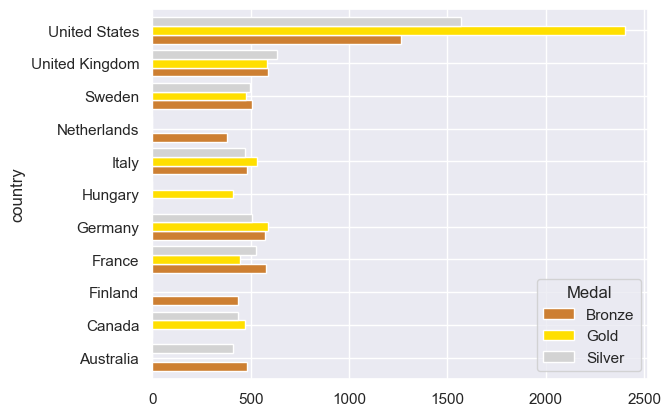

In [32]:
plt.figure(figsize=(20,20))
distr=df.groupby(['Country_y','Medal'])['Medal'].count().reset_index(name='count').sort_values(by='count',ascending=False).head(25)
distr.pivot_table(columns='Medal',index='Country_y',values='count').plot.barh(width=0.8,color=['#CD7F32','#FFDF00','#D3D3D3'])
plt.ylabel('country')
plt.show()
# distr

 1) Data Mergingm

In [33]:
summer.head()

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1896,Athens,Aquatics,Swimming,Alfred HAJOS,HUN,Men,100M Freestyle,Gold
1,1896,Athens,Aquatics,Swimming,Otto HERSCHMANN,AUT,Men,100M Freestyle,Silver
2,1896,Athens,Aquatics,Swimming,Dimitrios DRIVAS,GRE,Men,100M Freestyle For Sailors,Bronze
3,1896,Athens,Aquatics,Swimming,Ioannis MALOKINIS,GRE,Men,100M Freestyle For Sailors,Gold
4,1896,Athens,Aquatics,Swimming,Spiridon CHASAPIS,GRE,Men,100M Freestyle For Sailors,Silver


In [34]:
winter.head()

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1924,Chamonix,Biathlon,Biathlon,"BERTHET, G.",FRA,Men,Military Patrol,Bronze
1,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, C.",FRA,Men,Military Patrol,Bronze
2,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, Maurice",FRA,Men,Military Patrol,Bronze
3,1924,Chamonix,Biathlon,Biathlon,"VANDELLE, André",FRA,Men,Military Patrol,Bronze
4,1924,Chamonix,Biathlon,Biathlon,"AUFDENBLATTEN, Adolf",SUI,Men,Military Patrol,Gold


In [35]:
dictionary.head()

,Country,Code,Population,GDP per Capita
0,Afghanistan,AFG,32526562.0,594.323081
1,Albania,ALB,2889167.0,3945.217582
2,Algeria,ALG,39666519.0,4206.031232
3,American Samoa*,ASA,55538.0,NaN
4,Andorra,AND,70473.0,NaN


In [36]:
olympic=pd.concat([summer,winter],keys=['summer','winter'],names=['Edition']).reset_index().drop(columns='level_1')
olympic
olympic.rename(columns={'Country':'code'},inplace=True)

1] Data Cleaning

In [37]:
country=pd.read_csv('./codeing/country_code.csv')
country_code=dict(zip(country['Code_2'].str[0:2],country['COUNTRY']))
country_code
olympic['country']=olympic['code'].str[0:2].map(country_code)


In [38]:
olympic.head()

,Edition,Year,City,Sport,Discipline,Athlete,code,Gender,Event,Medal,country
0,summer,1896,Athens,Aquatics,Swimming,Alfred HAJOS,HUN,Men,100M Freestyle,Gold,Hungary
1,summer,1896,Athens,Aquatics,Swimming,Otto HERSCHMANN,AUT,Men,100M Freestyle,Silver,Australia
2,summer,1896,Athens,Aquatics,Swimming,Dimitrios DRIVAS,GRE,Men,100M Freestyle For Sailors,Bronze,Greece
3,summer,1896,Athens,Aquatics,Swimming,Ioannis MALOKINIS,GRE,Men,100M Freestyle For Sailors,Gold,Greece
4,summer,1896,Athens,Aquatics,Swimming,Spiridon CHASAPIS,GRE,Men,100M Freestyle For Sailors,Silver,Greece


In [39]:
olympic.tail()

,Edition,Year,City,Sport,Discipline,Athlete,code,Gender,Event,Medal,country
36930,winter,2014,Sochi,Skiing,Snowboard,"JONES, Jenny",GBR,Women,Slopestyle,Bronze,United Kingdom
36931,winter,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold,United States
36932,winter,2014,Sochi,Skiing,Snowboard,"MALTAIS, Dominique",CAN,Women,Snowboard Cross,Silver,Canada
36933,winter,2014,Sochi,Skiing,Snowboard,"SAMKOVA, Eva",CZE,Women,Snowboard Cross,Gold,Czech Republic
36934,winter,2014,Sochi,Skiing,Snowboard,"TRESPEUCH, Chloe",FRA,Women,Snowboard Cross,Bronze,France


In [40]:
olympic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36935 entries, 0 to 36934
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Edition     36935 non-null  object
 1   Year        36935 non-null  int64 
 2   City        36935 non-null  object
 3   Sport       36935 non-null  object
 4   Discipline  36935 non-null  object
 5   Athlete     36750 non-null  object
 6   code        36935 non-null  object
 7   Gender      36935 non-null  object
 8   Event       36935 non-null  object
 9   Medal       36935 non-null  object
 10  country     29084 non-null  object
dtypes: int64(1), object(10)
memory usage: 3.1+ MB


In [41]:
mode_of_olympic=olympic['Athlete'].mode()[0]
olympic.fillna(mode_of_olympic,inplace=True)                                        

In [42]:
olympic.isna().sum()

Edition       0
Year          0
City          0
Sport         0
Discipline    0
Athlete       0
code          0
Gender        0
Event         0
Medal         0
country       0
dtype: int64

Finding the missing data in the new dataframe

In [43]:
country=pd.read_csv('./codeing/country_code.csv')
country_code=dict(zip(country['Code_2'].str[0:2],country['COUNTRY']))
country_code
olympic['country']=olympic['code'].str[0:2].map(country_code)
olympic.head()

,Edition,Year,City,Sport,Discipline,Athlete,code,Gender,Event,Medal,country
0,summer,1896,Athens,Aquatics,Swimming,Alfred HAJOS,HUN,Men,100M Freestyle,Gold,Hungary
1,summer,1896,Athens,Aquatics,Swimming,Otto HERSCHMANN,AUT,Men,100M Freestyle,Silver,Australia
2,summer,1896,Athens,Aquatics,Swimming,Dimitrios DRIVAS,GRE,Men,100M Freestyle For Sailors,Bronze,Greece
3,summer,1896,Athens,Aquatics,Swimming,Ioannis MALOKINIS,GRE,Men,100M Freestyle For Sailors,Gold,Greece
4,summer,1896,Athens,Aquatics,Swimming,Spiridon CHASAPIS,GRE,Men,100M Freestyle For Sailors,Silver,Greece


List all of the old countries' codes

In [71]:
olympic['country'].value_counts()

country
United States     5238
France            2132
United Kingdom    1799
Georgia           1690
Australia         1630
                  ... 
Bangladesh           1
Sweden               1
Djibouti             1
Togo                 1
Gabon                1
Name: count, Length: 97, dtype: int64

In [82]:
olympic['Medal']=olympic['Medal'].sort_values(ascending=False)

In [84]:
olympic

,Edition,Year,City,Sport,Discipline,Athlete,code,Gender,Event,Medal,country
0,summer,1896,Athens,Aquatics,Swimming,Alfred HAJOS,HUN,Men,100M Freestyle,Gold,Hungary
1,summer,1896,Athens,Aquatics,Swimming,Otto HERSCHMANN,AUT,Men,100M Freestyle,Silver,Australia
2,summer,1896,Athens,Aquatics,Swimming,Dimitrios DRIVAS,GRE,Men,100M Freestyle For Sailors,Bronze,Greece
3,summer,1896,Athens,Aquatics,Swimming,Ioannis MALOKINIS,GRE,Men,100M Freestyle For Sailors,Gold,Greece
4,summer,1896,Athens,Aquatics,Swimming,Spiridon CHASAPIS,GRE,Men,100M Freestyle For Sailors,Silver,Greece
...,...,...,...,...,...,...,...,...,...,...,...
36930,winter,2014,Sochi,Skiing,Snowboard,"JONES, Jenny",GBR,Women,Slopestyle,Bronze,United Kingdom
36931,winter,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold,United States
36932,winter,2014,Sochi,Skiing,Snowboard,"MALTAIS, Dominique",CAN,Women,Snowboard Cross,Silver,Canada
36933,winter,2014,Sochi,Skiing,Snowboard,"SAMKOVA, Eva",CZE,Women,Snowboard Cross,Gold,Czech Republic


In [91]:
medal_order= ['Bronze', 'Silver', 'Gold']
olympic['Medal']=pd.Categorical(olympic['Medal'],categories=medal_order, ordered=True)


In [101]:
olympic['Medal']=olympic['Medal'].sort_values(ascending=False)

In [104]:
olympic['Medal'].sort_values(ascending=False)

0          Gold
11064      Gold
26059      Gold
26058      Gold
26057      Gold
          ...  
25815    Bronze
25816    Bronze
25817    Bronze
25818    Bronze
36934    Bronze
Name: Medal, Length: 36935, dtype: category
Categories (3, object): ['Bronze' < 'Silver' < 'Gold']

What are the Top 10 Countries by total medals?

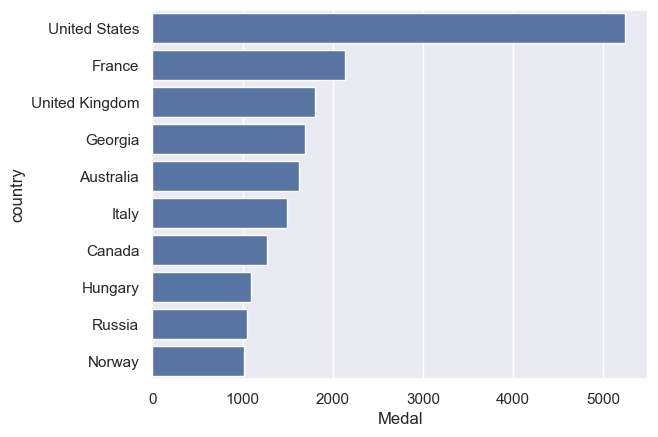

In [112]:
total_country=olympic.groupby('country')['Medal'].count().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=total_country,y='country',x='Medal')
plt.show()